In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data.csv', sep=';')

<font color = #006400><h1> Dataset Overview </h1> </font>

<font color = #006400><h2> General Statistics </h2> </font>

In [2]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDescribe:")
print(df.describe())

Shape: (4424, 37)

Data types:
Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                  

In [3]:
import pandas as pd

# select 8 important features
selected_columns = [
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Tuition fees up to date",
    "Debtor",
    "Admission grade",
    "Age at enrollment",
    "Scholarship holder",
    "Target"
]

# subset dataframe
df_selected = df[selected_columns]

# show first 5 rows
df_selected.head(5)

,Curricular units 1st sem (approved),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Tuition fees up to date,Debtor,Admission grade,Age at enrollment,Scholarship holder,Target
0,0,0,0.000000,1,0,127.3,20,0,Dropout
1,6,6,13.666667,0,0,142.5,19,0,Graduate
2,0,0,0.000000,0,0,124.8,19,0,Dropout
3,6,5,12.400000,1,0,119.6,20,0,Graduate
4,5,6,13.000000,1,0,141.5,45,0,Graduate


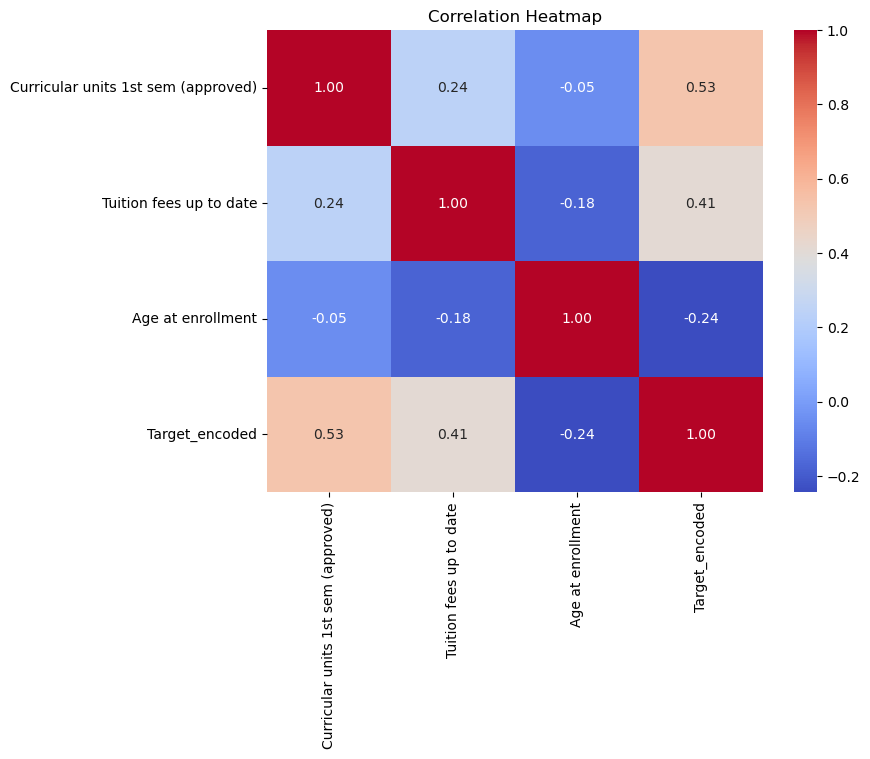

In [4]:
df['Target_encoded'] = df['Target'].map({
    'Dropout': 0,
    'Enrolled': 1,
    'Graduate': 2
})

cols = [
    'Curricular units 1st sem (approved)',
    'Tuition fees up to date',
    'Age at enrollment',
    'Target_encoded'
]

df_subset = df[cols]

corr = df_subset.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

<font color = #006400><h2> Class Distribution </h2> </font>

In [5]:
counts = df['Target'].value_counts()
pct = df['Target'].value_counts(normalize=True) * 100

print("Class distribution:")
print(pd.DataFrame({"count": counts, "percent (%)": pct.round(1)}).to_string())

Class distribution:
          count  percent (%)
Target                      
Graduate   2209         49.9
Dropout    1421         32.1
Enrolled    794         17.9


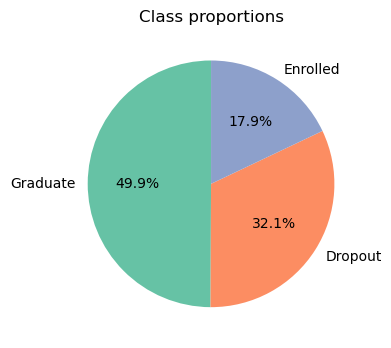

In [6]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(counts, labels=counts.index, autopct="%1.1f%%",
       startangle=90, colors=plt.cm.Set2.colors)
ax.set_title("Class proportions")

plt.tight_layout()
plt.show()

In [7]:
majority = counts.max() / counts.sum()
print(round(majority, 3))

0.499


<font color = #006400><h2> Dataset Summary </h2> </font>

<p>This dataset contains information about 4424 students enrolled in various undergraduate
programs at a Portuguese higher education institution. It includes 36 features</p>

<p>
    
Features include:
  <ul>
   <li>
  Demographics     : Marital status, Age at enrollment, Gender,
                     Nationality, International, Displaced
  </li>
    <li>
  Family background: Mother's/Father's qualification & occupation
  </li>
      <li>
  Admission        : Application mode, Application order, Course,
                     Admission grade, Previous qualification (grade)
            </li>
      <li>
  Finances         : Debtor, Tuition fees up to date, Scholarship holder
  </li>
      <li>
  Academic (sem 1) : Credited, Enrolled, Evaluations, Approved,
                     Grade, Without evaluations
                     </li>
      <li>
  Academic (sem 2) : Same 6 metrics as semester 1
  </li>
      <li>
  Economic context : Unemployment rate, Inflation rate, GDP
  </li>

  </ul>

</p>

<p>

The <b>target variable</b> has three classes:
Dropout, Enrolled, and Graduate. 
<br>
The dataset luckily has <b>no missing values</b>. <b>The goal</b> is to
predict whether a student will drop out, remain enrolled, or graduate.
</p>

<font color = #006400><h1> Visualisations </h1> </font>

## 1

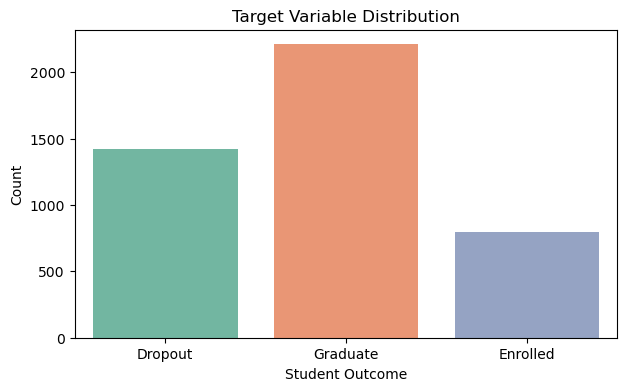

In [8]:
plt.figure(figsize=(7, 4))
sns.countplot(x='Target', data=df, palette='Set2')
plt.title('Target Variable Distribution')
plt.xlabel('Student Outcome')
plt.ylabel('Count')
plt.show()

<p>
    Graduate is the most common class (50%), followed by Dropout (32%) and Enrolled
(18%). The dataset is imbalanced — this must be considered when evaluating model
performance.
</p>

## 2

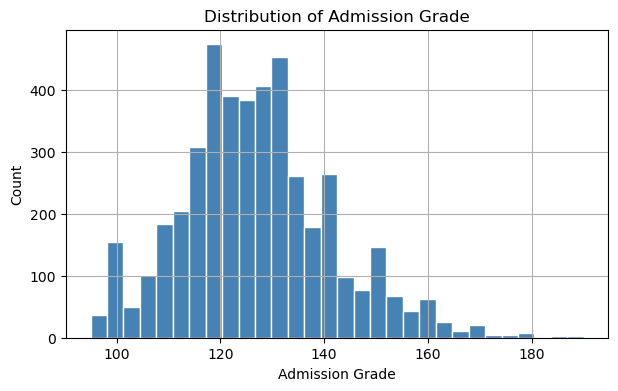

In [9]:
plt.figure(figsize=(7, 4))
df['Admission grade'].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Admission Grade')
plt.xlabel('Admission Grade')
plt.ylabel('Count')
plt.show()

<p>
    Admission grades follow a roughly normal distribution centered around 125-130. 
<br>    
Very
few students were admitted with grades below 100 or above 170, suggesting a
consistent selection process.
</p>

## 3

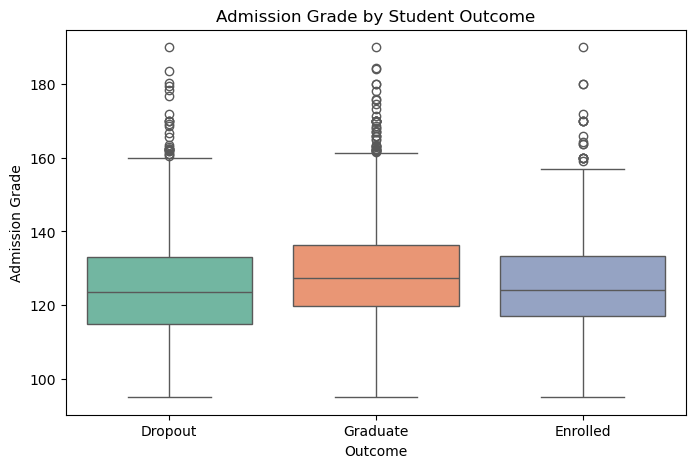

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Target', y='Admission grade', data=df, palette='Set2')
plt.title('Admission Grade by Student Outcome')
plt.xlabel('Outcome')
plt.ylabel('Admission Grade')
plt.show()

<p> Graduate students tend to have higher admission grades than dropouts. This suggests
admission grade is a useful predictor of student success. Dropouts show more variability
and a lower median grade.</p>

## 4

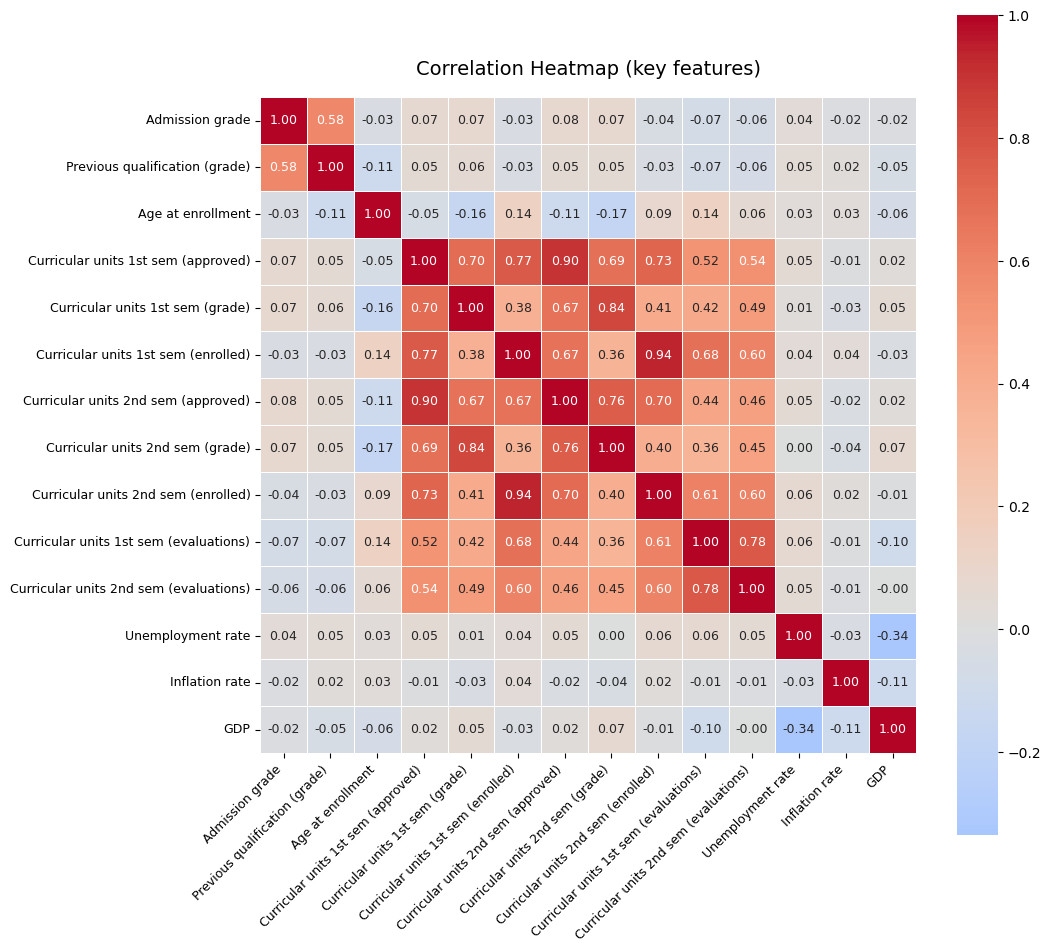

In [11]:
important_cols = [
    'Admission grade',
    'Previous qualification (grade)',
    'Age at enrollment',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 2nd sem (evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP',
]

corr = df[important_cols].corr()

plt.figure(figsize=(11, 10))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 9},
    linewidths=0.4,
    square=True
)
plt.title('Correlation Heatmap (key features)', fontsize=14, pad=16)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

<p>
Our data is too big to cover all the numeric columns in the heatmap, that's why we only filtered the most significant and important columns
</p>

<p>

 Curricular units approved in semester 1 and 2 are strongly positively correlated with each
other, suggesting consistent academic performance across semesters. Age at enrollment
shows a slight negative correlation with academic performance features, meaning older
students tend to perform slightly worse. Tuition fees up to date has a notable positive
correlation with graduation outcomes.
</p>

## 5

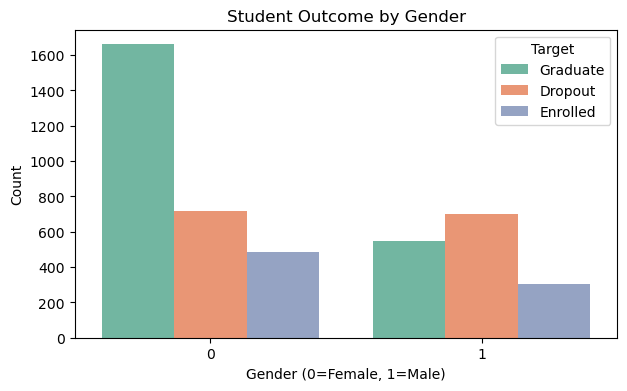

In [12]:
plt.figure(figsize=(7, 4))
sns.countplot(x='Gender', hue='Target', data=df, palette='Set2')
plt.title('Student Outcome by Gender')
plt.xlabel('Gender (0=Female, 1=Male)')
plt.ylabel('Count')
plt.show()

<p>
Female students (0) have a higher graduation rate relative to male students (1). Male
students show a higher dropout rate, suggesting gender is a relevant feature for
predicting student outcome.
</p>

## 6

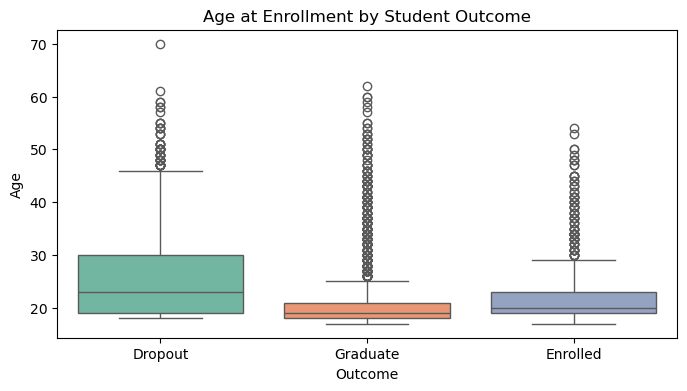

In [13]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='Target', y='Age at enrollment', data=df, palette='Set2')
plt.title('Age at Enrollment by Student Outcome')
plt.xlabel('Outcome')
plt.ylabel('Age')
plt.show()

<p>

Dropout students tend to be older at enrollment compared to graduates. This could
reflect mature-age students facing more external challenges such as work and family
commitments that interfere with study completion.
</p>

<font color = #006400><h1> Missing Value Handling </h1> </font>

<p>

This dataset contains no missing values as confirmed by isnull().sum() returning 0 for all
columns. Therefore no imputation or row removal is required. This is consistent with the
dataset documentation which states that preprocessing was already performed by the
creator
</p>

In [14]:
print(df.isnull().sum())

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

<font color = #006400><h1> Feature Engineering </h1> </font>

In [15]:
from sklearn.preprocessing import LabelEncoder

# ── 1. New feature: total approved units across both semesters ──
df['Total approved'] = (df['Curricular units 1st sem (approved)'] +
                        df['Curricular units 2nd sem (approved)'])

# ── 2. Encode Target (label encoding) ──────────────────────────
le = LabelEncoder()
df['Target_encoded'] = le.fit_transform(df['Target'])

print("Target classes:", list(le.classes_))
print("Mapped to     :", list(range(len(le.classes_))))

# ── 3. Encode Course (label encoding) ──────────────────────────
df['Course_encoded'] = le.fit_transform(df['Course'].astype(str))

print("\nSample of new columns:")
print(df[['Total approved', 'Target_encoded', 'Course_encoded']].head())

Target classes: ['Dropout', 'Enrolled', 'Graduate']
Mapped to     : [0, 1, 2]

Sample of new columns:
   Total approved  Target_encoded  Course_encoded
0               0               0               0
1              12               2              10
2               0               0               4
3              11               2              14
4              11               2               2


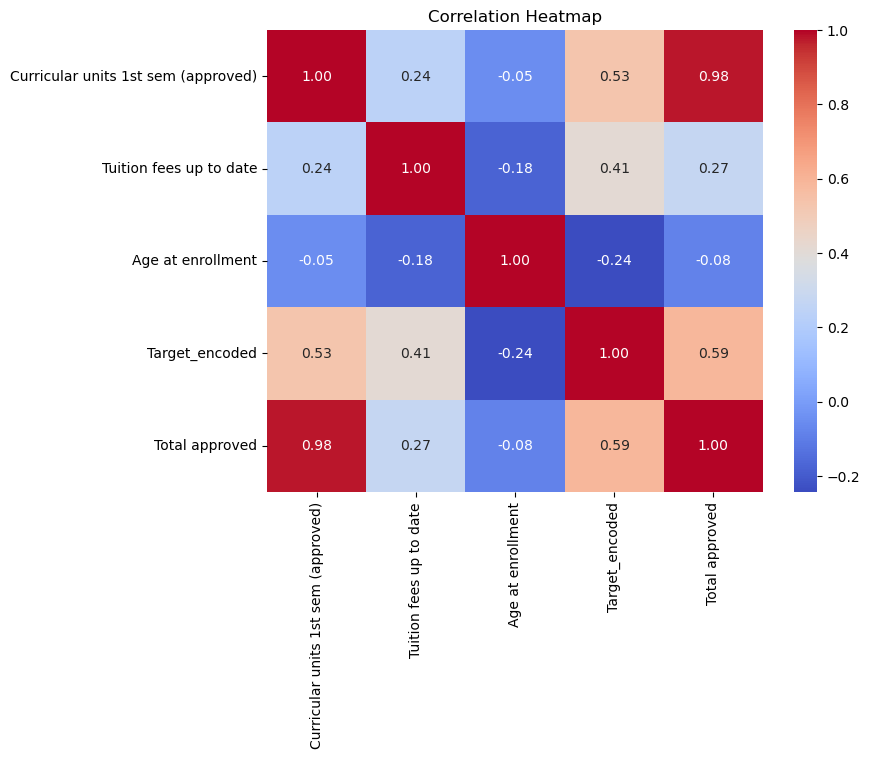

In [19]:
df['Target_encoded'] = df['Target'].map({
    'Dropout': 0,
    'Enrolled': 1,
    'Graduate': 2
})

cols = [
    'Curricular units 1st sem (approved)',
    'Tuition fees up to date',
    'Age at enrollment',
    'Target_encoded',
    'Total approved'
]

df_subset = df[cols]

corr = df_subset.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

<p><strong>Feature Engineering & Encoding</strong></p>

<p><strong>New feature — <code>Total approved</code></strong><br>
Sum of approved curricular units across semester 1 and semester 2.<br>
This captures overall academic progress in a single column, which is more directly predictive of student outcome than the two separate columns alone.</p>

<p><strong>Target encoding — Label Encoding</strong><br>
The <code>Target</code> column has 3 classes: <em>Graduate</em>, <em>Dropout</em>, and <em>Enrolled</em>.<br>
Since this is the output variable, label encoding (0, 1, 2) is appropriate — no algorithm will misinterpret the numeric ordering on a target label.</p>

<p><strong>Course encoding — Label Encoding</strong><br>
<code>Course</code> has high cardinality (many unique course IDs).<br>
One-hot encoding would create a large number of extra columns and bloat the dataset.<br>
Label encoding keeps it compact. This is justified because the planned algorithm is tree-based (e.g. Random Forest),<br>
which does not assume any numeric ordering between feature values.</p>

<font color = #006400><h1> Scaling & Preprocessing </h1> </font>

In [16]:
le = LabelEncoder()
df['Target_encoded'] = le.fit_transform(df['Target'])
print("Target classes:", le.classes_)
print(df['Target_encoded'].value_counts())

# Features and target
X = df.select_dtypes(include=np.number).drop(columns=['Target_encoded'])
y = df['Target_encoded']

# Train/test split — done BEFORE scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Target classes: ['Dropout' 'Enrolled' 'Graduate']
Target_encoded
2    2209
0    1421
1     794
Name: count, dtype: int64


<p><strong>Feature Scaling</strong></p>

<p><strong>Scaler choice — StandardScaler</strong><br>
<code>StandardScaler</code> is used over <code>MinMaxScaler</code> because the dataset contains outliers<br>
(e.g. admission grades, age at enrollment) and the planned algorithm is Random Forest.<br>
StandardScaler standardises features to zero mean and unit variance,<br>
making it more robust to outliers than MinMaxScaler which compresses everything into a fixed [0,1] range.</p>

<p><strong>Avoiding data leakage</strong><br>
The scaler is fitted exclusively on <code>X_train</code> using <code>scaler.fit_transform(X_train)</code>.<br>
<code>X_test</code> is only transformed using <code>scaler.transform(X_test)</code> — never fitted.<br>
This ensures no information from the test set influences the preprocessing,<br>
which would artificially inflate model performance.</p>

<font color = #006400><h1> Train/Test Split </h1> </font>

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (3539, 38)
X_test:  (885, 38)
y_train: (3539,)
y_test:  (885,)


<p><strong>Train/Test Split</strong></p>

<p><strong>Split configuration</strong><br>
The dataset is split into 80% training and 20% test sets using <code>train_test_split</code><br>
with <code>test_size=0.2</code> and <code>random_state=42</code>.<br>
A fixed random state ensures the split is reproducible across runs.</p>

<p><strong>Split before scaling</strong><br>
The train/test split is performed before any scaling is applied.<br>
This is the correct order — fitting the scaler after the split on training data only<br>
prevents any test set information from leaking into the preprocessing step.</p>

In [18]:
# ─────────────────────────────────────────
# BASELINE MODEL 1: Logistic Regression
# ─────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# ── 1. Prepare features and target ──────
X = df.drop(columns=['Target'])
y = df['Target']  # Graduate / Dropout / Enrolled

# ── 2. Train/test split ─────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 3. Scale features ───────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── 4. Train Logistic Regression ────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# ── 5. Predictions & Metrics ────────────
y_pred = lr.predict(X_test_scaled)

print("=" * 50)
print("BASELINE — Logistic Regression")
print("=" * 50)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

BASELINE — Logistic Regression

Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000

Classification Report:
              precision    recall  f1-score   support

     Dropout       1.00      1.00      1.00       284
    Enrolled       1.00      1.00      1.00       159
    Graduate       1.00      1.00      1.00       442

    accuracy                           1.00       885
   macro avg       1.00      1.00      1.00       885
weighted avg       1.00      1.00      1.00       885

Confusion Matrix:
[[284   0   0]
 [  0 159   0]
 [  0   0 442]]
